In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

# 1. CRIANDO O DATAFRAME PARA O EXERCÍCIO
data = {
    'id_sensor': [101, 102, 103, 104, 101, 105, 106, 107, 108, 109],
    'localizacao': ['Setor A', 'Setor B', 'Setor A', 'Setor C', 'Setor A', 'Setor B', 'Setor C', 'Setor A', np.nan, 'Setor B'],
    'consumo_kwh': [150.5, 3200.0, 150.5, 2100.0, 150.5, np.nan, 4500.0, 120.0, 5000.0, 250.0],
    'temperatura_operacao': [25.4, 65.2, 25.4, np.nan, 25.4, 40.0, 85.0, 22.0, 90.0, 30.5],
    'status': ['Ativo', 'Alerta', 'Ativo', 'Inativo', 'Ativo', 'Ativo', 'Alerta', 'Ativo', 'Critico', 'Inativo']
}

df = pd.DataFrame(data)

In [40]:
df.drop_duplicates()
df.loc[:, 'localizacao'] = df['localizacao'].fillna(df['localizacao'].mode()[0])
df.loc[:, 'consumo_kwh'] = df['consumo_kwh'].fillna(df['consumo_kwh'].mean())
df.loc[:, 'temperatura_operacao'] = df['temperatura_operacao'].fillna(df['temperatura_operacao'].mean())

df_encoded = pd.get_dummies(df, columns=['localizacao', 'status'])

scaler = MinMaxScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

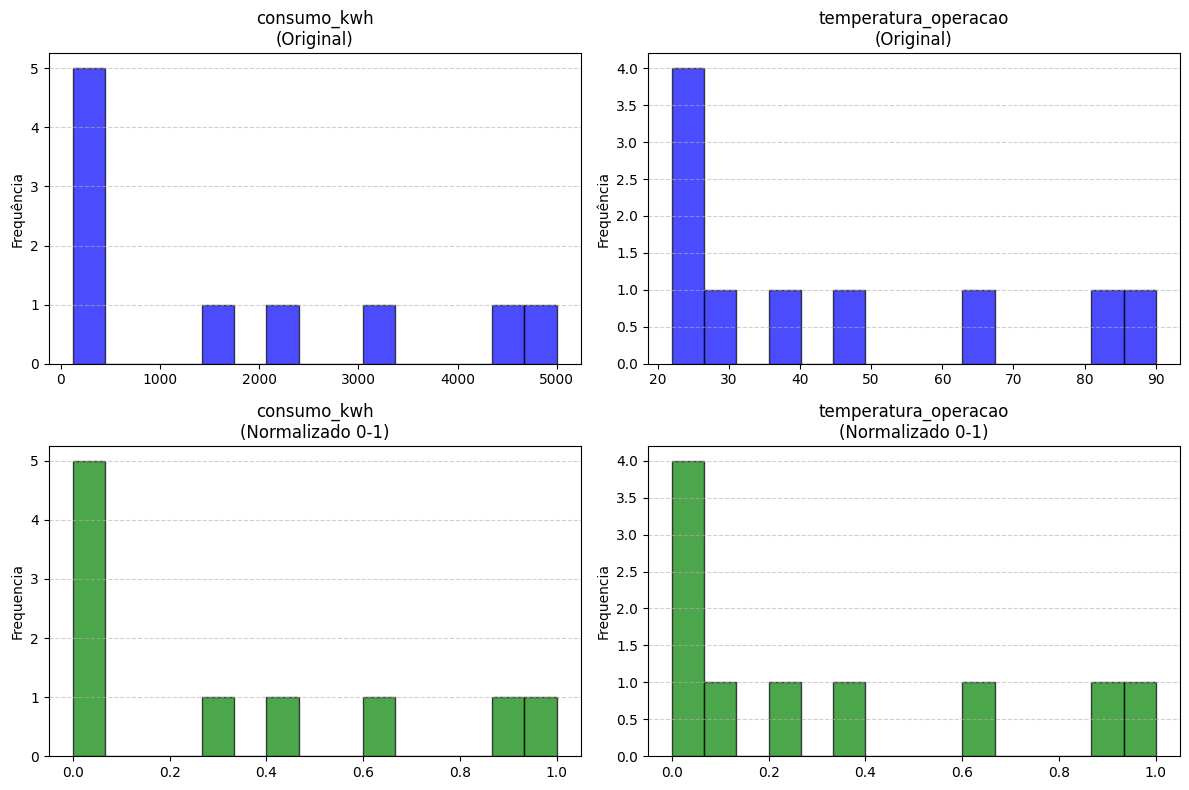

In [51]:
cols_numericas = ['consumo_kwh', 'temperatura_operacao']


plt.figure(figsize=(12, 8))

for i, col in enumerate(cols_numericas):
    plt.subplot(2,len(cols_numericas), i + 1 )
    plt.hist(df_encoded[col], bins = 15, alpha = 0.7, color='blue', edgecolor='black')
    plt.title(f"{col}\n(Original)")
    plt.ylabel('Frequência')
    plt.grid(axis='y', linestyle='--', alpha = 0.6)

    plt.subplot(2, len(cols_numericas), i + 1 + len(cols_numericas))
    plt.hist(df_norm[col], bins = 15, alpha = 0.7, color='green', edgecolor='black')
    plt.title(f"{col}\n(Normalizado 0-1)")
    plt.ylabel('Frequencia')
    plt.grid(axis='y',linestyle='--', alpha =0.6)
plt.tight_layout()
plt.show()